# Üretim Verisinden Günlük Enerji Tüketimi Tahmini

Bu proje, bir üretim tesisinin günlük üretim verilerini (işlenen parça adedi,
malzeme türüne göre ağırlıklar, toplam işlem/rota süresi) kullanarak günlük
elektrik enerjisi tüketimini tahmin eden uçtan uca bir makine öğrenmesi
çalışmasıdır.

**Not — veri hakkında:** Bu depoda kullanılan veri (`data/sentetik_uretim_enerji.csv`)
gerçek bir şirketin verisi değildir; gerçek bir projede karşılaşılan yapı ve veri
kalitesi sorunlarını (boşta çalışma günleri, sensör/sayaç kayıpları) yansıtacak
şekilde **sentetik olarak üretilmiştir** (bkz. `generate_synthetic_data.py`).
Analiz akışı ve karar süreci, gerçek bir üretim ortamında yürütülen çalışmanın
birebir aynısıdır.

**Kullanılan araçlar:** Python, pandas, scikit-learn (RandomForestRegressor), matplotlib.


## 1. Veriyi Yükle ve Tanı

Her tablo verisi projesinde olduğu gibi, önce veriyi yükleyip genel yapısına bakıyoruz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/sentetik_uretim_enerji.csv", parse_dates=["Tarih"])
print(df.shape)
df.head()

(260, 20)


,Tarih,Uretilen_Adet,Toplam_Rota_Suresi,Uretim_Net_Kg,Uretim_Brut_Kg,Pik_Adet,Sfr_Adet,Adi_Adet,Tipi_Bos_Adet,Kontrol,Pik_Yuzde,Sfr_Yuzde,Pik_Net_Kg,Sfr_Net_Kg,Adi_Net_Kg,Tipi_Bos_Net_Kg,Kontrol_Kg,Pik_Kg_Yuzde,Sfr_Kg_Yuzde,Enerji_kWh
0,2024-01-01,426,7814.54,5831.03,5833.67,250,129,28,19,0,0.586854,0.302817,3201.42,2414.41,189.52,25.67,0,0.549032,0.414063,2565.78
1,2024-01-02,938,19561.56,11590.66,11590.66,422,265,156,95,0,0.449893,0.282516,5130.81,4915.36,1267.84,276.65,0,0.442668,0.424079,5265.99
2,2024-01-03,904,13309.21,10488.30,10488.30,392,273,213,26,0,0.433628,0.301991,4166.62,4428.81,1878.09,14.78,0,0.397263,0.422262,3935.94
3,2024-01-04,1032,12385.55,13664.53,13665.20,601,314,83,34,0,0.582364,0.304264,7827.32,5126.01,641.59,69.61,0,0.572820,0.375133,4121.02
4,2024-01-05,994,12418.39,11002.62,11002.62,551,315,99,29,0,0.554326,0.316901,5344.14,4626.46,991.03,40.99,0,0.485715,0.420487,3981.70


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Tarih               260 non-null    datetime64[us]
 1   Uretilen_Adet       260 non-null    int64         
 2   Toplam_Rota_Suresi  260 non-null    float64       
 3   Uretim_Net_Kg       260 non-null    float64       
 4   Uretim_Brut_Kg      260 non-null    float64       
 5   Pik_Adet            260 non-null    int64         
 6   Sfr_Adet            260 non-null    int64         
 7   Adi_Adet            260 non-null    int64         
 8   Tipi_Bos_Adet       260 non-null    int64         
 9   Kontrol             260 non-null    int64         
 10  Pik_Yuzde           260 non-null    float64       
 11  Sfr_Yuzde           260 non-null    float64       
 12  Pik_Net_Kg          260 non-null    float64       
 13  Sfr_Net_Kg          260 non-null    float64       
 14  Adi_N

## 2. Veri Temizliği

### 2.1 Bilgi taşımayan sütunlar

`Kontrol` ve `Kontrol_Kg` sütunlarının her satırda sabit (0) olup olmadığını kontrol
edelim — sabitse modele hiçbir bilgi katmazlar.


In [3]:
print(df['Kontrol'].describe())
print(df['Kontrol_Kg'].describe())

df = df.drop(columns=['Kontrol', 'Kontrol_Kg'])
df.shape

count    260.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Kontrol, dtype: float64
count    260.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Kontrol_Kg, dtype: float64


(260, 18)

### 2.2 Sensör / sayaç kaybı

Gerçek dünya enerji verilerinde sık karşılaşılan bir durum: bazı günlerde üretim
gerçekleşmiş olmasına rağmen kayıtlı enerji tüketimi 0 görünebilir — bu fiziksel
olarak mümkün değildir. Genelde bunun sebebi, o günün ölçümünün kaybolup bir
sonraki günün toplamına yansıtılmasıdır (sayaç/sensör okuma problemi).

Bunu tespit etmek için "üretim > 0 ama enerji == 0" olan günleri arıyoruz.


In [4]:
kayip_gunler = df[(df['Uretilen_Adet'] > 0) & (df['Enerji_kWh'] == 0)]
print("Şüpheli (kayıp veri) gün sayısı:", len(kayip_gunler))
kayip_gunler[['Tarih', 'Uretilen_Adet', 'Enerji_kWh']]

Şüpheli (kayıp veri) gün sayısı: 2


,Tarih,Uretilen_Adet,Enerji_kWh
37,2024-02-07,1143,0.0
151,2024-05-31,669,0.0


In [5]:
# Bu günleri izleyen günün enerji değeri anormal yüksek mi, kontrol edelim
for idx in kayip_gunler.index:
    print(df.loc[max(0, idx-1):idx+2, ['Tarih', 'Uretilen_Adet', 'Enerji_kWh']])
    print('---')

        Tarih  Uretilen_Adet  Enerji_kWh
36 2024-02-06            883     2500.79
37 2024-02-07           1143        0.00
38 2024-02-08            500     9335.43
39 2024-02-09            816     2741.26
---
         Tarih  Uretilen_Adet  Enerji_kWh
150 2024-05-30            894     3803.57
151 2024-05-31            669        0.00
152 2024-06-01              0     6373.97
153 2024-06-02              0     1951.27
---


İzleyen günlerde enerji değerinin normalin oldukça üzerinde olduğunu görüyoruz —
bu, kaybolan ölçümün bir sonraki güne eklendiğini doğruluyor. Hem sıfır enerjili
günü hem de onu izleyen "kontamine" (birden fazla günün verisini taşıyan) günü
veri setinden çıkarıyoruz.


In [6]:
cikar_idx = set()
for idx in kayip_gunler.index:
    cikar_idx.add(idx)
    if idx + 1 in df.index:
        cikar_idx.add(idx + 1)

print("Çıkarılan satır sayısı:", len(cikar_idx))
df = df.drop(index=list(cikar_idx)).reset_index(drop=True)
df.shape

Çıkarılan satır sayısı: 4


(256, 18)

### 2.3 Boşta çalışma günleri

Üretimin sıfır olduğu günlerde bile bir miktar enerji tüketimi (aydınlatma,
bekleme modu, taban yük) kaydedilmiş olabilir. Bu çalışmanın amacı **üretimin**
enerjiyi nasıl etkilediğini öğrenmek olduğundan, bu günleri (farklı bir tüketim
rejimini temsil ettikleri için) modelden çıkarıyoruz.


In [7]:
print("Üretim=0 gün sayısı:", (df['Uretilen_Adet'] == 0).sum())

df = df[df['Uretilen_Adet'] > 0].reset_index(drop=True)
df.shape

Üretim=0 gün sayısı: 84


(172, 18)

## 3. Özellik Seçimi

Bazı sütunlar, başka sütunlardan türetilmiş olabilir ve modele yeni bir bilgi
katmaz. Bunları tespit edip çıkaralım.

**a) Yüzde sütunları** (`Pik_Yuzde`, `Sfr_Yuzde`, `Pik_Kg_Yuzde`, `Sfr_Kg_Yuzde`):
zaten var olan adet/kg sütunlarının oranı.

**b) Toplam ağırlık sütunları** (`Uretim_Net_Kg`, `Uretim_Brut_Kg`): malzeme
türüne göre kırılımların (Pik + Sfr + Adi + Tipi Boş) toplamına eşit olabilir.


In [8]:
fark = (df['Uretim_Net_Kg'] - (df['Pik_Net_Kg'] + df['Sfr_Net_Kg'] + df['Adi_Net_Kg'] + df['Tipi_Bos_Net_Kg'])).abs()
print("Uretim_Net_Kg ile malzeme kırılımı toplamı arasındaki en büyük fark:", fark.max())

Uretim_Net_Kg ile malzeme kırılımı toplamı arasındaki en büyük fark: 0.020000000002255547


Fark neredeyse sıfır — yani `Uretim_Net_Kg`, malzeme türü kırılımının toplamından
başka bir şey değil. Toplam yerine kırılımı (malzeme türüne göre ayrı ayrı ağırlıkları)
kullanmak daha bilgilendirici, çünkü model hangi malzeme türünün enerjiyi ne kadar
etkilediğini de öğrenebilir.

### Bir hipotez testi: "talaş miktarı" (brüt − net) enerjiyle ilişkili mi?

Talaşlı imalatta makine, brüt (ham) malzemeden talaş kaldırarak net (bitmiş) parçaya
ulaşır — akla gelen bir soru: kaldırılan talaş miktarı enerjiyle ilişkili olabilir mi?


In [9]:
df['Talas_Kg'] = df['Uretim_Brut_Kg'] - df['Uretim_Net_Kg']
df['Talas_Kg'].describe()

count    172.000000
mean       1.405523
std        1.758444
min        0.000000
25%        0.000000
50%        0.700000
75%        2.262500
max        8.110000
Name: Talas_Kg, dtype: float64

Bu veri setinde brüt/net farkı neredeyse hep sıfıra yakın — yani bu iki sütun,
beklenen "talaş kaybı" bilgisini taşımıyor (muhtemelen farklı bir şeyi ölçüyorlar,
ör. ambalaj ağırlığı). Hipotezi veriyle test ettik ve veri desteklemedi, bu
özelliği kullanmıyoruz. **Bu da değerli bir sonuç: her hipotez veriyle
doğrulanmayı hak eder, sezgiyle kabul edilmemeli.**


In [10]:
ozellikler = ['Toplam_Rota_Suresi', 'Uretilen_Adet', 'Pik_Net_Kg', 'Sfr_Net_Kg', 'Adi_Net_Kg', 'Tipi_Bos_Net_Kg']
X = df[ozellikler]
y = df['Enerji_kWh']
print(X.shape, y.shape)

(172, 6) (172,)


## 4. Eğitim / Test Ayrımı ve Model

Veriyi %80 eğitim / %20 test olarak ayırıp, `RandomForestRegressor` ile eğitiyoruz.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.1f} kWh")
print(f"R²: {r2:.3f}")
print(f"Ortalama enerji (test): {y_test.mean():.1f} kWh")
print(f"Bağıl hata (MAE / ortalama): %{100*mae/y_test.mean():.1f}")

MAE: 248.6 kWh
R²: 0.925
Ortalama enerji (test): 3880.5 kWh
Bağıl hata (MAE / ortalama): %6.4


## 5. Özellik Önemi

In [12]:
onem = pd.Series(model.feature_importances_, index=ozellikler).sort_values(ascending=False)
onem

Toplam_Rota_Suresi    0.889626
Sfr_Net_Kg            0.035861
Uretilen_Adet         0.035854
Pik_Net_Kg            0.022884
Tipi_Bos_Net_Kg       0.008252
Adi_Net_Kg            0.007524
dtype: float64

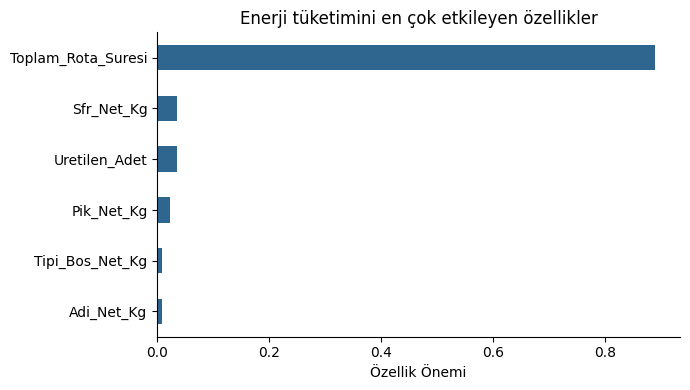

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
onem.sort_values().plot(kind='barh', ax=ax, color='#2f6690')
ax.set_xlabel('Özellik Önemi')
ax.set_title('Enerji tüketimini en çok etkileyen özellikler')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ozellik_onemi.png', dpi=130)
plt.show()

## 6. Gerçek vs. Tahmin


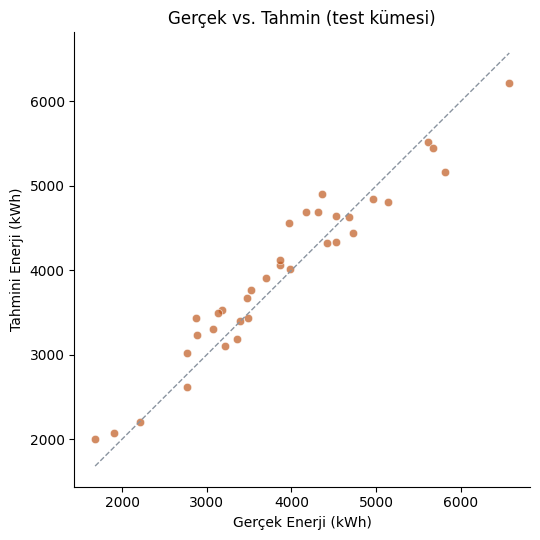

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred, alpha=0.7, color='#c05a1f', edgecolor='white', linewidth=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color='#8a94a0', linestyle='--', linewidth=1)
ax.set_xlabel('Gerçek Enerji (kWh)')
ax.set_ylabel('Tahmini Enerji (kWh)')
ax.set_title('Gerçek vs. Tahmin (test kümesi)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('gercek_vs_tahmin.png', dpi=130)
plt.show()

## 7. Tahmin Fonksiyonu

Modeli, yeni bir üretim planı için tahmin üretecek şekilde bir fonksiyona sarıyoruz.


In [15]:
def enerji_tahmin_et(sure, adet, pik_kg, sfr_kg, adi_kg, bos_kg):
    yeni_veri = pd.DataFrame({
        'Toplam_Rota_Suresi': [sure],
        'Uretilen_Adet': [adet],
        'Pik_Net_Kg': [pik_kg],
        'Sfr_Net_Kg': [sfr_kg],
        'Adi_Net_Kg': [adi_kg],
        'Tipi_Bos_Net_Kg': [bos_kg],
    })
    return model.predict(yeni_veri)[0]

# örnek kullanım — medyan değerlerle
ornek = X.median()
enerji_tahmin_et(*ornek.values)

np.float64(4086.2614000000003)

## 8. Modeli Kaydet

Eğitilmiş modeli diske kaydedip, ileride yeniden eğitmeden kullanabiliriz.


In [16]:
import joblib
joblib.dump(model, "enerji_modeli.pkl")

['enerji_modeli.pkl']

## Sonuç

- Enerji tüketimini en çok belirleyen unsur **toplam işlem/rota süresi**.
- Malzeme türüne göre ağırlık kırılımı, toplam ağırlıktan daha bilgilendirici.
- Veri kalitesi sorunları (sensör/sayaç kaybı, boşta çalışma günleri) doğru
  tespit edilip ele alınmadan, model yanlış örüntüler öğrenebilir.
- Bir "web tabanlı tahmin aracı" versiyonu için `web-tool/` klasörüne bakabilirsiniz
  (eğitilmiş modeli tarayıcıda çalıştıran, sunucu gerektirmeyen statik bir sayfa).
